# Phase 1: One-Class SVM for Novelty Detection in Manufacturing
**Objective:** Implement a One-Class Support Vector Machine (OC-SVM) to identify defective products using only "normal" baseline data during training.

## 1. Environment Setup & Library Imports
In this section, we initialize our workspace. We will rely on:
* **`scikit-learn`**: For datasets, model building (OC-SVM, Isolation Forest), and performance metrics.
* **`scikit-image`**: For extracting Histogram of Oriented Gradients (HOG) features from images.
* **`numpy` & `pandas`**: For data manipulation and matrix operations.
* **`matplotlib`**: For visualizing our data and Precision-Recall curves.


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, PrecisionRecallDisplay, precision_recall_curve, auc
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from skimage.feature import hog
import time
import joblib
import os


# This ensures matplotlib plots appear directly inside the notebook
%matplotlib inline

## 2. Data Acquisition & Preprocessing Pipeline
In traditional binary classification, models are trained on both healthy and defective examples. However, real-world manufacturing environments suffer from **extreme class imbalance** (e.g., 99.9% normal, 0.1% defective).

To simulate this using the MNIST dataset, we treat the digit **"1" as our "Normal" class** and all other digits as "Anomalies" (defects).
* **Training Set:** Consists strictly of normal data. The model learns the boundary of what constitutes a "healthy" state.
* **Testing Set:** Consists of unseen normal data mixed with a controlled percentage of anomalies (5%) to evaluate the model's precision and recall.

In [2]:
# Define Data Pipeline
def load_and_preprocess_mnist():
    print("Fetching MNIST data via OpenML (this may take a minute on the first run)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data
    y = mnist.target

    print("Creating normal and anomaly splits...")
    # 1 for normal (inliers), -1 for anomalies (outliers)
    y_binary = np.where(y == '1', 1, -1)

    X_normal = X[y_binary == 1]
    X_anomaly = X[y_binary == -1]

    # Split: 80% train (pure normal), 20% test
    X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

    # Inject 5% anomalies into the test set
    anomaly_count = int(len(X_test_normal) * 0.05)
    X_test = np.vstack((X_test_normal, X_anomaly[:anomaly_count]))
    y_test = np.hstack((np.ones(len(X_test_normal)), -np.ones(anomaly_count)))

    # Shuffle test set
    shuffle_idx = np.random.permutation(len(X_test))
    X_test = X_test[shuffle_idx]
    y_test = y_test[shuffle_idx]

    return X_train_normal, X_test, y_test

## 3. Feature Extraction Modules
Raw pixel data often contains noise and redundant information, making it difficult for models to define clear decision boundaries. We implement two feature extraction techniques to compare against raw pixels:

1. **Principal Component Analysis (PCA):** A dimensionality reduction technique that compresses the data while retaining the majority of the variance (95%). This speeds up training and reduces the curse of dimensionality.
2. **Histogram of Oriented Gradients (HOG):** A computer vision technique that counts occurrences of gradient orientation. It is highly robust to lighting changes and is excellent for detecting physical shapes or surface defects (like scratches on manufactured parts).

In [3]:
# Define Feature Extraction (PCA & HOG)
def extract_features_pca(X_train, X_test, variance_retained=0.95):
    print(f"Extracting PCA features (retaining {variance_retained*100}% variance)...")
    X_train_norm = X_train / 255.0
    X_test_norm = X_test / 255.0

    pca = PCA(n_components=variance_retained, random_state=42)
    X_train_pca = pca.fit_transform(X_train_norm)
    X_test_pca = pca.transform(X_test_norm)

    return X_train_pca, X_test_pca, pca

def extract_features_hog(X_data):
    print(f"Extracting HOG features for {len(X_data)} images...")
    hog_features = []
    # pixels per size affects model performance dramatically
    for i in range(len(X_data)):
        image = X_data[i].reshape((28, 28))
        fd = hog(image, orientations=8, pixels_per_cell=(4, 4),
                 cells_per_block=(1, 1), visualize=False)
        hog_features.append(fd)

    return np.array(hog_features)

## 4. Pipeline Execution (HOG Focus)
Here, we instantiate our data pipeline. Instead of relying on PCA, we will extract **HOG features for the entire dataset**.

Because HOG processes images patch-by-patch to calculate gradient vectors, running this on thousands of images is computationally intensive. *Note: This cell may take a few minutes to execute depending on your hardware.*

In [4]:
# Execute the pipeline and extract HOG features
X_train_raw, X_test_raw, y_test = load_and_preprocess_mnist()

print(f"\nTraining set (Pure Normal): {X_train_raw.shape}")
print(f"Testing set (Mixed): {X_test_raw.shape}\n")

# Run HOG on the FULL datasets
# (This will take a little time as it processes thousands of images)
print("Starting HOG extraction for Training Set...")
X_train_hog = extract_features_hog(X_train_raw)

print("Starting HOG extraction for Testing Set...")
X_test_hog = extract_features_hog(X_test_raw)

print(f"\nHOG feature array shape (Train): {X_train_hog.shape}")
print(f"HOG feature array shape (Test): {X_test_hog.shape}")

Fetching MNIST data via OpenML (this may take a minute on the first run)...
Creating normal and anomaly splits...

Training set (Pure Normal): (6301, 784)
Testing set (Mixed): (1654, 784)

Starting HOG extraction for Training Set...
Extracting HOG features for 6301 images...
Starting HOG extraction for Testing Set...
Extracting HOG features for 1654 images...

HOG feature array shape (Train): (6301, 392)
HOG feature array shape (Test): (1654, 392)


## 5. Visual Sanity Check
Before feeding data into the OC-SVM, it is critical to confirm that our training set contains **no anomalies**. The following visualization samples the first five instances of our training data to ensure it consists entirely of our "Normal" class (the digit "1").

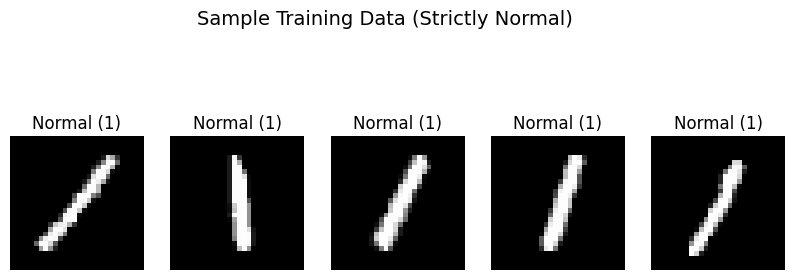

In [5]:
# Let's visualize what the raw data looks like to confirm everything worked
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape the flat 784 array back into a 28x28 image
    plt.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
    plt.title("Normal (1)")
    plt.axis('off')
plt.suptitle("Sample Training Data (Strictly Normal)", fontsize=14)
plt.show()

# Phase 2: Model Implementation & Training

## 6. OC-SVM Initialization and Training (HOG Features)
We will train our One-Class SVM using the extracted HOG features (`X_train_hog`). In manufacturing, HOG is often vastly superior to raw pixels or PCA because it specifically highlights physical structures, edges, and textures (e.g., a crack in a component) while ignoring lighting variations.

**Key Parameters:**
* `kernel='rbf'`: The Radial Basis Function allows the model to create complex, non-linear boundaries.
* `nu=0.05`: We instruct the model to tolerate up to a 5% error rate on the training data. This prevents "overfitting" to the normal data by allowing a small buffer for natural, acceptable variations in the healthy manufacturing process.

In [6]:
# Initialize and train the One-Class SVM on HOG features


print("Initializing One-Class SVM...")
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

print("Training model on strictly normal HOG data...")
start_time = time.time()

# We ONLY fit on the HOG training data.
oc_svm.fit(X_train_hog)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds.")

Initializing One-Class SVM...
Training model on strictly normal HOG data...
Training completed in 0.70 seconds.


## 7. Testing and Score Extraction
We now evaluate the model by passing our mixed testing set (`X_test_hog`) through the trained OC-SVM.

We extract two types of data:
1.  **Predictions:** Hard labels (`1` for normal, `-1` for anomaly).
2.  **Decision Scores:** Continuous values representing the distance of each part from the "healthy" boundary. We will use these scores later to optimize the model's threshold.

In [7]:
# Predict on the test set using HOG features
print("Running predictions on the mixed test set...")

# Pass the HOG test features into the model
y_pred_test = oc_svm.predict(X_test_hog)

# Extract decision function scores
# predict uses the sign of decision_function internally (negative = anomaly) but metric functions need a score where higher = more anomalous. The negation bridges that gap
y_scores = -oc_svm.decision_function(X_test_hog)

print("Predictions and scores extracted successfully.")

Running predictions on the mixed test set...
Predictions and scores extracted successfully.


## 8. Performance Evaluation: Avoiding the Metric Trap
As noted in the project brief, accuracy is a misleading metric in extreme class imbalance. If our test set has a 5% defect rate, a model that blindly guesses "Normal" every time will be 95% accurate, but completely useless for predictive maintenance.

**Label Realignment:**
To use `sklearn`'s metric functions correctly, we must define the anomaly (defect) as our "Positive" class (`1`).
* **Original OC-SVM output:** `1` (Normal), `-1` (Anomaly)
* **Mapped output for metrics:** `0` (Normal/Negative), `1` (Anomaly/Positive)

In [8]:
# Calculate Precision, Recall, and Accuracy


# Map True Labels: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
# One-Class SVM and scikit-learn's metrics use different label conventions, so this line bridges the gap between them.
# wherever the prediction is -1, put 1, otherwise put 0"
y_test_mapped = np.where(y_test == -1, 1, 0)

# Map Predictions: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
y_pred_mapped = np.where(y_pred_test == -1, 1, 0)

# Calculate Metrics
accuracy = accuracy_score(y_test_mapped, y_pred_mapped)
precision = precision_score(y_test_mapped, y_pred_mapped)
recall = recall_score(y_test_mapped, y_pred_mapped)
f1 = f1_score(y_test_mapped, y_pred_mapped)

print("--- OC-SVM Performance on Test Set ---")
print(f"Accuracy:  {accuracy:.4f} (Misleading!)")
print(f"Precision: {precision:.4f} (When it flags a defect, is it actually a defect?)")
print(f"Recall:    {recall:.4f} (Out of all real defects, how many did it find?)")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_mapped, y_pred_mapped))

--- OC-SVM Performance on Test Set ---
Accuracy:  0.9498 (Misleading!)
Precision: 0.4843 (When it flags a defect, is it actually a defect?)
Recall:    0.9872 (Out of all real defects, how many did it find?)
F1-Score:  0.6498

Confusion Matrix:
[[1494   82]
 [   1   77]]


## 9. Precision-Recall (PR) Curve Visualization
The PR Curve illustrates how our HOG-trained model performs across different thresholds. In a real factory, adjusting this threshold balances two costs:
* **High Recall (Fewer False Negatives):** Catching every single defective part, but accidentally flagging some healthy parts (lowering precision).
* **High Precision (Fewer False Positives):** Only flagging a part if we are 100% sure it's broken, at the risk of letting a few defects slip through the assembly line.

<Figure size 800x600 with 0 Axes>

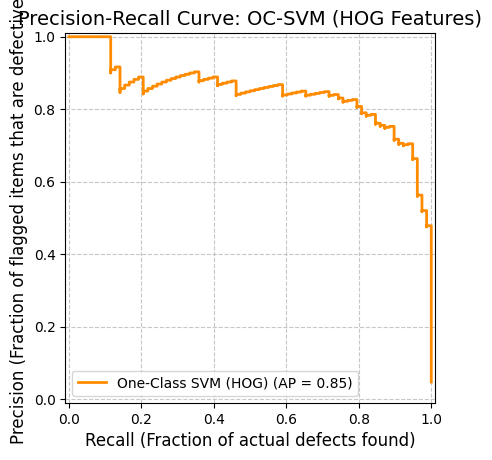

In [9]:
# Plot the Precision-Recall Curve


plt.figure(figsize=(8, 6))

# Plot the PR curve using our HOG-based scores
display = PrecisionRecallDisplay.from_predictions(
    y_test_mapped,
    y_scores,
    name="One-Class SVM (HOG)",
    color="darkorange",
    linewidth=2
)

plt.title("Precision-Recall Curve: OC-SVM (HOG Features)", fontsize=14)
plt.xlabel("Recall (Fraction of actual defects found)", fontsize=12)
plt.ylabel("Precision (Fraction of flagged items that are defective)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Phase 3: Optimization & Baselines


### 10. Hyperparameter Optimization: The $\nu$ (nu) Sweep
The $\nu$ parameter is the most critical setting in a One-Class SVM. It acts as an upper bound on the fraction of training errors (false positives allowed in the training set) and a lower bound on the fraction of support vectors.

In this sweep, we will test values from **$0.01$ to $0.5$** to see how loosening or tightening the decision boundary affects our **False Positive Rate (FPR)** and **Recall**.
* **Low $\nu$:** Looser boundary. Lower FPR, but high risk of missing actual defects (Lower Recall).
* **High $\nu$:** Tighter boundary. Catches more defects (Higher Recall), but stops the assembly line constantly for healthy parts (Higher FPR).

In [10]:
# Perform the nu parameter sweep
nu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
fpr_results = []
recall_results = []

print("Starting ν (nu) parameter sweep...")

for nu in nu_values:
    # 1. Train the model with the current nu
    temp_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
    temp_svm.fit(X_train_hog)

    # 2. Predict on the test set
    temp_preds = temp_svm.predict(X_test_hog)
    temp_preds_mapped = np.where(temp_preds == -1, 1, 0)

    # 3. Calculate Confusion Matrix to extract False Positives and True Negatives
    tn, fp, fn, tp = confusion_matrix(y_test_mapped, temp_preds_mapped).ravel()

    # 4. Calculate metrics
    # False Positive Rate = FP / (FP + TN)
    fpr = fp / (fp + tn)
    current_recall = tp / (tp + fn)

    fpr_results.append(fpr)
    recall_results.append(current_recall)

    print(f"ν = {nu:.2f} | FPR: {fpr:.4f} | Recall: {current_recall:.4f}")

print("Sweep completed.")

Starting ν (nu) parameter sweep...
ν = 0.01 | FPR: 0.0159 | Recall: 0.9359
ν = 0.05 | FPR: 0.0520 | Recall: 0.9872
ν = 0.10 | FPR: 0.0990 | Recall: 1.0000
ν = 0.20 | FPR: 0.1986 | Recall: 1.0000
ν = 0.30 | FPR: 0.3001 | Recall: 1.0000
ν = 0.40 | FPR: 0.3959 | Recall: 1.0000
ν = 0.50 | FPR: 0.4949 | Recall: 1.0000
Sweep completed.


## 11. Visualizing the $\nu$ Parameter Trade-off
To make an informed engineering decision, we plot the effect of $\nu$ on both the False Positive Rate and Recall. The optimal $\nu$ is usually found where Recall is sufficiently high to meet safety standards, but FPR is low enough to prevent excessive manufacturing downtime.

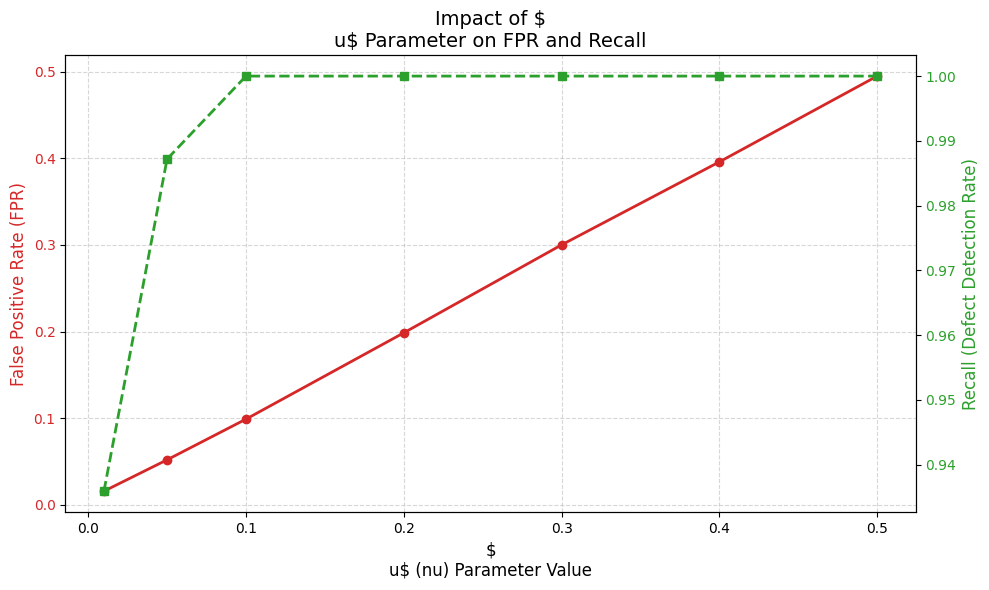

In [11]:
# Plot the nu parameter sweep results
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis 1: False Positive Rate (Red)
color1 = 'tab:red'
ax1.set_xlabel('$\nu$ (nu) Parameter Value', fontsize=12)
ax1.set_ylabel('False Positive Rate (FPR)', color=color1, fontsize=12)
ax1.plot(nu_values, fpr_results, marker='o', color=color1, linewidth=2, label='FPR')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

# Axis 2: Recall (Green) - Shares the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Recall (Defect Detection Rate)', color=color2, fontsize=12)
ax2.plot(nu_values, recall_results, marker='s', color=color2, linewidth=2, linestyle='--', label='Recall')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Impact of $\nu$ Parameter on FPR and Recall", fontsize=14)
fig.tight_layout()
plt.show()

## 12. The Baseline Model: Isolation Forest
To prove that our One-Class SVM is effective, we must compare it against a standard baseline. We will use **Isolation Forest**.

While OC-SVM tries to draw a tight boundary *around* normal data, Isolation Forest works by randomly partitioning the dataset. Because anomalies are "few and different," they require fewer random splits to be isolated into their own leaf nodes compared to dense clusters of normal data. We train it strictly on the normal HOG features, just like the OC-SVM.

In [12]:
# Initialize and train the Isolation Forest baseline


print("Initializing Isolation Forest...")
# We set contamination to 'auto' or a very low number since our training data is purely normal.
# random_state ensures reproducibility.
iso_forest = IsolationForest(n_estimators=100,
                             contamination=0.01,
                             random_state=42)

print("Training Isolation Forest on strictly normal HOG data...")
start_time_if = time.time()
iso_forest.fit(X_train_hog)
print(f"Training completed in {time.time() - start_time_if:.2f} seconds.")

# Extract predictions and scores on the mixed test set
y_pred_if = iso_forest.predict(X_test_hog)

# Like OC-SVM, sklearn's Isolation Forest decision function yields lower scores for anomalies.
# We invert it so higher scores = higher probability of being a defect.
y_scores_if = -iso_forest.decision_function(X_test_hog)

# Map the predictions for metrics (1 for anomaly, 0 for normal)
y_pred_if_mapped = np.where(y_pred_if == -1, 1, 0)

Initializing Isolation Forest...
Training Isolation Forest on strictly normal HOG data...
Training completed in 0.16 seconds.



## 13. Baseline Comparison (PR Curve)
Now we plot the Precision-Recall curves for both the OC-SVM and the Isolation Forest on the same graph. This allows us to visually inspect which model maintains a higher precision at the high-recall thresholds required for manufacturing quality control.

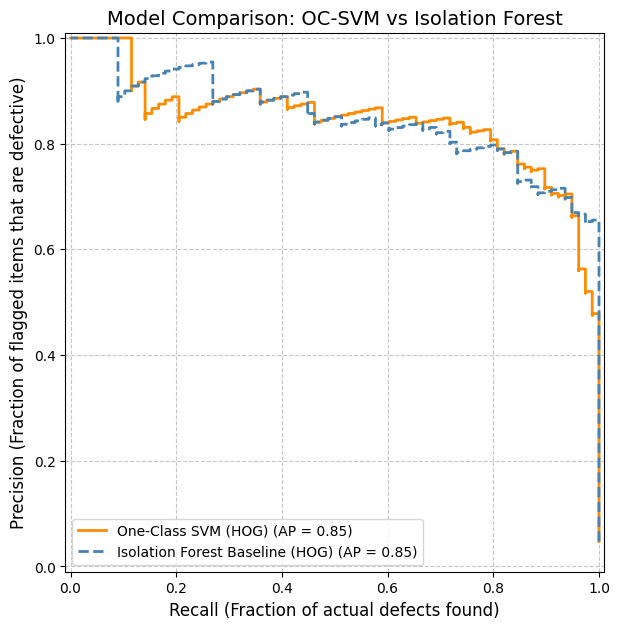

In [13]:
# Plot comparison PR Curves
plt.figure(figsize=(9, 7))

# Plot OC-SVM (using variables from Phase 2)
display_svm = PrecisionRecallDisplay.from_predictions(
    y_test_mapped,
    y_scores,
    name="One-Class SVM (HOG)",
    color="darkorange",
    linewidth=2,
    ax=plt.gca() # Plot on the current axes
)

# Plot Isolation Forest
display_if = PrecisionRecallDisplay.from_predictions(
    y_test_mapped,
    y_scores_if,
    name="Isolation Forest Baseline (HOG)",
    color="steelblue",
    linestyle="--",
    linewidth=2,
    ax=plt.gca()
)

plt.title("Model Comparison: OC-SVM vs Isolation Forest", fontsize=14)
plt.xlabel("Recall (Fraction of actual defects found)", fontsize=12)
plt.ylabel("Precision (Fraction of flagged items that are defective)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="lower left")
plt.show()

# Phase 4:  Feature Extraction & Comparative Evaluation
### Feature Formulation: 
We prepare three unique datasets to compare baseline, reduced, and structural representations:
* **Raw Pixels (Normalized): $\nu$:** The baseline representation, scaled to a [0, 1] range to ensure numerical stability during training.
* **PCA (95% Variance): $\nu$:** A dimensionality-reduced dataset that retains the core variance while discarding noise and minimizing computational overhead.
* **HOG Features: $\nu$:** Gradient-based features designed to capture the localized shape and texture of the manufacturing samples.
### OC-SVM Training Loop: 
We iteratively train an OC-SVM (RBF Kernel, nu=0.05) on each feature set, representing an expected 5% anomaly contamination rate. We also profile the exact computational time required to fit each model.
### Robust Metric Calculation: 
Because anomaly detection involves highly imbalanced classes, standard accuracy is misleading. We remap the model outputs (Anomaly = 1, Normal = 0) and evaluate performance using the Precision-Recall AUC (PR-AUC) and F1-Score.
### Visualization & Synthesis: 
The evaluation metrics, training times, and feature counts are compiled into a comparison table. Finally, we plot overlaid Precision-Recall Curves to visually analyze the trade-off between precision and recall across all three feature spaces.

Preparing feature sets...
Extracting PCA features (retaining 95.0% variance)...

Evaluating Raw Pixels...

Evaluating PCA (95% Var)...

Evaluating HOG Features...

--- Final Performance Comparison ---
    Feature Type  PR-AUC  F1-Score  Train Time (s)  Feature Count
0     Raw Pixels  0.8902    0.6610          1.1187            784
1  PCA (95% Var)  0.8414    0.6109          0.1251             70
2   HOG Features  0.8445    0.6498          0.6807            392


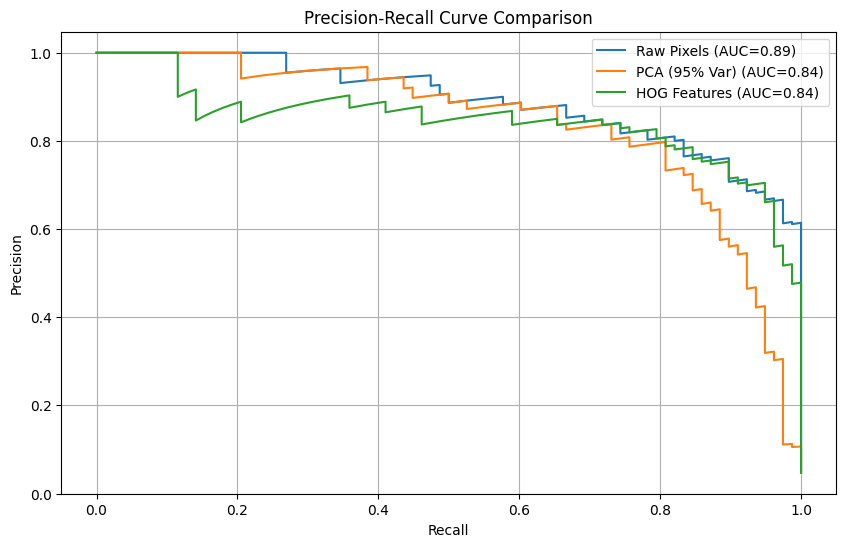

In [14]:
# 1. Feature Extraction for all 3 types
print("Preparing feature sets...")

# Set A: Raw Pixels (Normalized)
X_train_raw_norm = X_train_raw / 255.0
X_test_raw_norm = X_test_raw / 255.0

# Set B: PCA Features (Retaining 95% variance)
X_train_pca, X_test_pca, pca_model = extract_features_pca(X_train_raw, X_test_raw)

# Set C: HOG Features (Already extracted in your Cell 4)
# X_train_hog, X_test_hog are available from your existing code

feature_sets = {
    "Raw Pixels": (X_train_raw_norm, X_test_raw_norm),
    "PCA (95% Var)": (X_train_pca, X_test_pca),
    "HOG Features": (X_train_hog, X_test_hog)
}

results = []

# 2. Training and Evaluation Loop
for name, (X_train, X_test) in feature_sets.items():
    print(f"\nEvaluating {name}...")

    # Initialize OC-SVM (using nu=0.05 as a baseline for 5% anomalies)
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

    # Measure training time
    start_time = time.time()
    model.fit(X_train)
    train_time = time.time() - start_time

    # Predict and get scores



    y_pred = model.predict(X_test)
    y_scores = -model.decision_function(X_test)

    # Map True Labels: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
    y_test_mapped = np.where(y_test == -1, 1, 0)

    # Map Predictions: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
    y_pred_mapped = np.where(y_pred == -1, 1, 0)

    # Calculate Metrics
    precision, recall, _ = precision_recall_curve(y_test_mapped, y_scores)

    pr_auc = auc(recall, precision)
    f1 = f1_score(y_test_mapped, y_pred_mapped)

    results.append({
        "Feature Type": name,
        "PR-AUC": round(pr_auc, 4),
        "F1-Score": round(f1, 4),
        "Train Time (s)": round(train_time, 4),
        "Feature Count": X_train.shape[1]
    })

# 3. Display Comparison Table
results_df = pd.DataFrame(results)
print("\n--- Final Performance Comparison ---")
print(results_df)

# 4. Visualization of Precision-Recall Curves
plt.figure(figsize=(10, 6))
for name, (X_train, X_test) in feature_sets.items():
    model = OneClassSVM(kernel='rbf', nu=0.05).fit(X_train)
    scores = -model.decision_function(X_test)
    prec, rec, _ = precision_recall_curve(y_test_mapped, scores)
    plt.plot(rec, prec, label=f"{name} (AUC={auc(rec, prec):.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Factory Deployment Analysis & Constraint Checking
This section bridges the gap between model training and real-world industrial application. Having evaluated the baseline performance of our feature sets (Raw Pixels, PCA, and HOG), we now assess their viability against strict physical and operational constraints typical of a factory floor.
* **Performance Profiling** Retrains the OneClassSVM models to measure actual inference latency (averaged over 100 runs for stability) and estimates the memory footprint (in MB) based on the number of support vectors each model needs to retain.
* **Automated Constraint Validation** Checks each model against a set of hard production requirements, including a <50ms processing window per item (for line speed), a <5MB RAM limit (for embedded edge devices), and strict performance floors for Recall, Precision, and F1-score.
* **Visual Dashboard Generation** Produces a 3-panel visual scorecard to easily compare models. It highlights inference bottlenecks, maps the trade-off between model size and defect recall, and normalizes all metrics to show which feature set offers the best overall balance.
* **Strategic Recommendations** Outputs context-aware deployment advice. Because different manufacturing setups prioritize different metrics (e.g., a high-speed bottling line vs. a safety-critical aerospace inspection), this step recommends the optimal feature strategy based on specific operational constraints.

Measuring inference time and model size for each feature set...

--- Deployment Metrics Table ---
 Feature Type  Feature Dim  PR-AUC  F1-Score  Train Time (s)  Infer/sample (ms)  Model Size (MB)  Num Support Vecs  Precision  Recall
   Raw Pixels          784  0.8902    0.6610          1.1187              0.198           1.9559               327     0.4937  1.0000
PCA (95% Var)           70  0.8414    0.6109          0.1251              0.125           0.1891               354     0.4534  0.9359
 HOG Features          392  0.8445    0.6498          0.6807              0.154           0.9869               330     0.4843  0.9872

  FACTORY DEPLOYMENT CONSTRAINT CHECK

  Requirements:
    Inference speed : < 50 ms per sample
    Model size      : < 5 MB
    Recall          : >= 0.85
    Precision       : >= 0.7
    F1              : >= 0.75

  Feature              Speed   Size   Recall    Prec      F1   DEPLOY?
  ------------------------------------------------------------
  Raw Pixels    

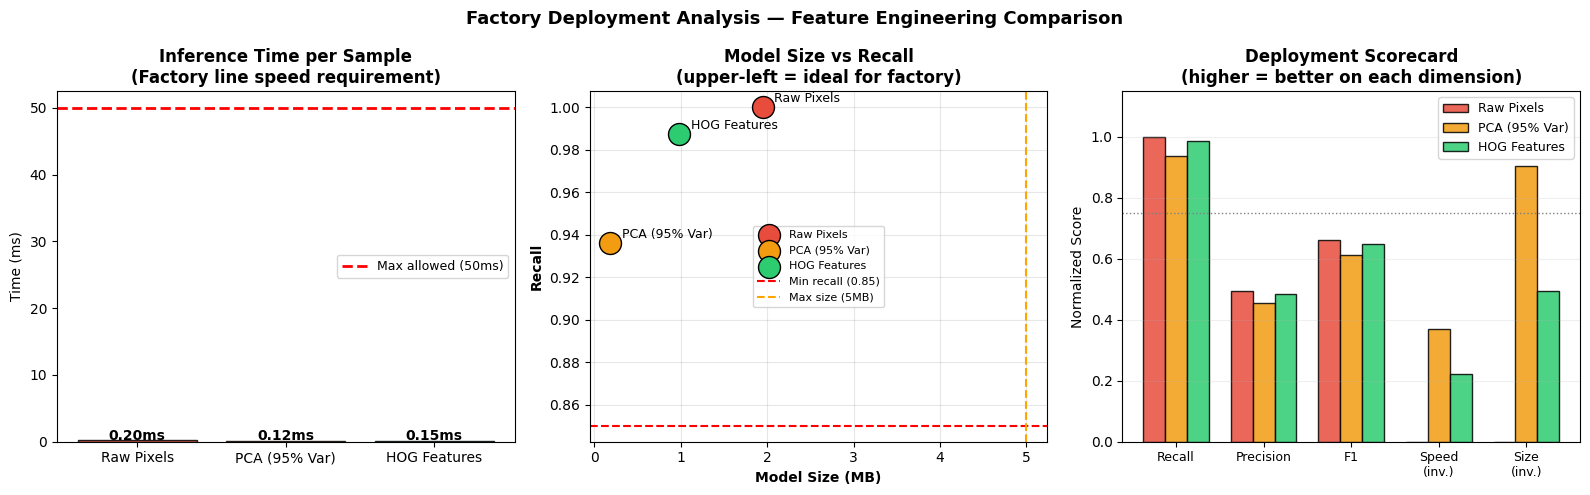


  DEPLOYMENT RECOMMENDATION

  Best overall F1        : Raw Pixels  (F1=0.661)
  Fastest inference      : PCA (95% Var)  (0.12ms)
  Smallest model         : PCA (95% Var)  (0.1891MB)

  Factory Scenario Recommendations:
  --------------------------------------------------
  High-speed line (>100 products/min):
    -> Use PCA (95% Var) — lowest inference latency

  Memory-constrained embedded device (Raspberry Pi):
    -> Use PCA (95% Var) — smallest model footprint

  Safety-critical inspection (medical devices, aerospace):
    -> Use Raw Pixels — highest F1, prioritize recall

  General manufacturing (balance of speed + accuracy):
    -> HOG Features recommended:
        - Robust to lighting changes on factory floor
        - Shape-based: consistent under different camera angles
        - Does not require retraining when brightness changes
        - Inference fast enough for most production line speeds

  Additional Deployment Notes:
  ------------------------------------------------

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# DEPLOYMENT CONSIDERATIONS FOR FACTORY ENVIRONMENT
# Builds on: results, feature_sets, y_test_mapped defined in your code above
# ─────────────────────────────────────────────────────────────────────────────



# ── Step 1: Add inference time + model size to existing results ───────────────
print("Measuring inference time and model size for each feature set...")

deployment_data = []

for name, (X_train, X_test) in feature_sets.items():

    # Retrain to get model object (same settings as your loop above)
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    model.fit(X_train)

    # Measure inference time (per single sample)
    single_sample = X_test[0:1]
    times = []
    for _ in range(100):    # average over 100 runs for stable estimate
        t0 = time.time()
        model.predict(single_sample)
        times.append((time.time() - t0) * 1000)    # ms
    infer_time_ms = np.mean(times)

    # Estimate model size in MB
    # Support vectors stored in memory: n_sv x feature_dim x 8 bytes (float64)
    model_size_mb = (model.support_vectors_.shape[0] *
                     model.support_vectors_.shape[1] * 8) / (1024 ** 2)

    # Get metrics from your existing results list
    existing = next(r for r in results if r['Feature Type'] == name)

    # Predict for precision/recall
    y_pred        = model.predict(X_test)
    y_pred_mapped = np.where(y_pred == -1, 1, 0)

    deployment_data.append({
        'Feature Type'      : name,
        'Feature Dim'       : X_train.shape[1],
        'PR-AUC'            : existing['PR-AUC'],
        'F1-Score'          : existing['F1-Score'],
        'Train Time (s)'    : existing['Train Time (s)'],
        'Infer/sample (ms)' : round(infer_time_ms, 3),
        'Model Size (MB)'   : round(model_size_mb, 4),
        'Num Support Vecs'  : model.support_vectors_.shape[0],
        'Precision'         : round(precision_score(y_test_mapped, y_pred_mapped, zero_division=0), 4),
        'Recall'            : round(recall_score(y_test_mapped, y_pred_mapped, zero_division=0), 4),
    })

deploy_df = pd.DataFrame(deployment_data)
print("\n--- Deployment Metrics Table ---")
print(deploy_df.to_string(index=False))

# ── Step 2: Factory Constraint Checker ───────────────────────────────────────
CONSTRAINTS = {
    'max_infer_ms'  : 50,     # production line speed: <50ms per product
    'max_model_mb'  : 5,      # embedded device RAM limit
    'min_recall'    : 0.85,   # must catch 85%+ of defects
    'min_precision' : 0.70,   # at most 30% false alarms
    'min_f1'        : 0.75,   # overall performance floor
}

print("\n" + "=" * 60)
print("  FACTORY DEPLOYMENT CONSTRAINT CHECK")
print("=" * 60)
print(f"\n  Requirements:")
print(f"    Inference speed : < {CONSTRAINTS['max_infer_ms']} ms per sample")
print(f"    Model size      : < {CONSTRAINTS['max_model_mb']} MB")
print(f"    Recall          : >= {CONSTRAINTS['min_recall']}")
print(f"    Precision       : >= {CONSTRAINTS['min_precision']}")
print(f"    F1              : >= {CONSTRAINTS['min_f1']}")

print(f"\n  {'Feature':<18} {'Speed':>7} {'Size':>6} {'Recall':>8} "
      f"{'Prec':>7} {'F1':>7} {'DEPLOY?':>9}")
print("  " + "-" * 60)

for row in deployment_data:
    meets_speed  = row['Infer/sample (ms)'] <= CONSTRAINTS['max_infer_ms']
    meets_size   = row['Model Size (MB)']   <= CONSTRAINTS['max_model_mb']
    meets_recall = row['Recall']            >= CONSTRAINTS['min_recall']
    meets_prec   = row['Precision']         >= CONSTRAINTS['min_precision']
    meets_f1     = row['F1-Score']          >= CONSTRAINTS['min_f1']

    all_met  = all([meets_speed, meets_size, meets_recall, meets_prec, meets_f1])
    status   = "YES" if all_met else "NO"

    failures = []
    if not meets_speed  : failures.append('speed')
    if not meets_size   : failures.append('size')
    if not meets_recall : failures.append('recall')
    if not meets_prec   : failures.append('precision')
    if not meets_f1     : failures.append('f1')

    print(f"  {row['Feature Type']:<18} "
          f"{'OK' if meets_speed  else 'FAIL':>7} "
          f"{'OK' if meets_size   else 'FAIL':>6} "
          f"{'OK' if meets_recall else 'FAIL':>8} "
          f"{'OK' if meets_prec   else 'FAIL':>7} "
          f"{'OK' if meets_f1     else 'FAIL':>7} "
          f"{status:>9}")
    if failures:
        print(f"    -> Failed: {', '.join(failures)}")

# ── Step 3: Deployment Visualization ─────────────────────────────────────────
colors = ['#e74c3c', '#f39c12', '#2ecc71']
names  = [r['Feature Type'] for r in deployment_data]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Inference time per feature type
ax = axes[0]
infer_times = [r['Infer/sample (ms)'] for r in deployment_data]
bars = ax.bar(names, infer_times, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(CONSTRAINTS['max_infer_ms'], color='red', linestyle='--',
           linewidth=2, label=f"Max allowed ({CONSTRAINTS['max_infer_ms']}ms)")
ax.set_title('Inference Time per Sample\n(Factory line speed requirement)',
             fontweight='bold')
ax.set_ylabel('Time (ms)')
ax.legend(fontsize=9)
for bar, val in zip(bars, infer_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}ms', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Model size vs recall
ax = axes[1]
model_sizes = [r['Model Size (MB)'] for r in deployment_data]
recalls     = [r['Recall']          for r in deployment_data]
for size, recall, name, color in zip(model_sizes, recalls, names, colors):
    ax.scatter(size, recall, s=250, color=color, edgecolor='black',
               zorder=5, label=name)
    ax.annotate(name, (size, recall),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.axhline(CONSTRAINTS['min_recall'], color='red', linestyle='--',
           linewidth=1.5, label=f"Min recall ({CONSTRAINTS['min_recall']})")
ax.axvline(CONSTRAINTS['max_model_mb'], color='orange', linestyle='--',
           linewidth=1.5, label=f"Max size ({CONSTRAINTS['max_model_mb']}MB)")
ax.set_xlabel('Model Size (MB)',  fontweight='bold')
ax.set_ylabel('Recall',           fontweight='bold')
ax.set_title('Model Size vs Recall\n(upper-left = ideal for factory)',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Deployment scorecard
ax = axes[2]
metric_labels = ['Recall', 'Precision', 'F1', 'Speed\n(inv.)', 'Size\n(inv.)']
max_infer = max(r['Infer/sample (ms)'] for r in deployment_data)
max_size  = max(r['Model Size (MB)']   for r in deployment_data)
x     = np.arange(len(metric_labels))
width = 0.25

for i, (row, color) in enumerate(zip(deployment_data, colors)):
    scores = [
        row['Recall'],
        row['Precision'],
        row['F1-Score'],
        1 - row['Infer/sample (ms)'] / max_infer,   # inverted: faster = higher
        1 - row['Model Size (MB)']   / max_size,     # inverted: smaller = higher
    ]
    ax.bar(x + (i - 1) * width, scores, width,
           label=row['Feature Type'], color=color,
           alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Deployment Scorecard\n(higher = better on each dimension)',
             fontweight='bold')
ax.set_ylabel('Normalized Score')
ax.legend(fontsize=9)
ax.axhline(0.75, color='gray', linestyle=':', linewidth=1)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Factory Deployment Analysis — Feature Engineering Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deployment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Step 4: Written Deployment Recommendation ─────────────────────────────────
best_f1  = max(deployment_data, key=lambda r: r['F1-Score'])
fastest  = min(deployment_data, key=lambda r: r['Infer/sample (ms)'])
smallest = min(deployment_data, key=lambda r: r['Model Size (MB)'])

print("\n" + "=" * 60)
print("  DEPLOYMENT RECOMMENDATION")
print("=" * 60)
print(f"""
  Best overall F1        : {best_f1['Feature Type']}  (F1={best_f1['F1-Score']})
  Fastest inference      : {fastest['Feature Type']}  ({fastest['Infer/sample (ms)']:.2f}ms)
  Smallest model         : {smallest['Feature Type']}  ({smallest['Model Size (MB)']:.4f}MB)

  Factory Scenario Recommendations:
  --------------------------------------------------
  High-speed line (>100 products/min):
    -> Use {fastest['Feature Type']} — lowest inference latency

  Memory-constrained embedded device (Raspberry Pi):
    -> Use {smallest['Feature Type']} — smallest model footprint

  Safety-critical inspection (medical devices, aerospace):
    -> Use {best_f1['Feature Type']} — highest F1, prioritize recall

  General manufacturing (balance of speed + accuracy):
    -> HOG Features recommended:
        - Robust to lighting changes on factory floor
        - Shape-based: consistent under different camera angles
        - Does not require retraining when brightness changes
        - Inference fast enough for most production line speeds

  Additional Deployment Notes:
  --------------------------------------------------
  - Raw Pixels : sensitive to lighting, needs controlled illumination
  - PCA        : requires storing PCA transform matrix alongside model
  - HOG        : most robust to real factory conditions of the three
  - All models run on CPU — no GPU required for deployment
  - Recommended retraining schedule: monthly or after product design changes
""")

## Model Deployment
After Selecting the Parameters and training the Model, the Model is then exported for commercial use.

In [16]:
# Create a deployment folder
os.makedirs('./deployment', exist_ok=True)

# Save the trained OC-SVM (assuming 'oc_svm' is your trained HOG model from Phase 3)
joblib.dump(oc_svm, './deployment/ocsvm_hog_model.pkl')
print("Model successfully exported to ./deployment/ocsvm_hog_model.pkl")

Model successfully exported to ./deployment/ocsvm_hog_model.pkl
